# Feature Engineering

In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('../data/processed/final_before_feng.csv',index_col=0).dropna()

## Target transform

In [3]:
df['price_log']=np.log(df['price_avg'])

## Construct new features

### group feature

#### brand group

In [4]:
top10=df['brand'].value_counts().head(10).index
df['brand_group']=np.where(df['brand'].isin(top10),df['brand'],'other')
# df['brand_group']=df['brand'].apply(lambda x: x if x in top10 else 'others')

#### segment group

In [5]:
conlist=[df['segment'].str.contains('微型'),
          df['segment'].str.contains('小型'),
          df['segment'].str.contains('紧凑型'),
         df['segment'].str.contains('中型'),
         df['segment'].str.contains('大型|中大型')]
choicelist=['micro','small','compact','medium','large']
df['size']=np.select(conlist,choicelist,default='other')

In [6]:
df['body_type']=df['segment'].str.extract(r'(SUV|轿车|MPV)').fillna('other')

## Categorical encoding

In [7]:
object_cols = df.select_dtypes(include=['object']).columns
# 1. Target encoding for brand_group and brand_category
for col in ['brand_group', 'brand_category']:
    target_mean = df.groupby(col)['price_log'].mean()
    df[col + '_encoded'] = df[col].map(target_mean)
    df = df.drop(columns=[col])

# 2. One-hot encoding for low cardinality categoricals
onehot_cols = ['powertrain', 'ADAS_Level', 'battery_type_clean', 
               'battery_supplier_clean', 'body_type', 'size']

df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)

# 3. Check final columns
print(f"Final feature count: {df.shape[1]}")
print(df.columns.tolist())

Final feature count: 35
['year', 'brand', 'model', 'segment', 'length_mm', 'width_mm', 'depth_mm', 'wheel_base', 'battery_capacity_avg', 'range_CLTC_avg', 'price_avg', 'seats', 'has_lidar', 'price_log', 'brand_group_encoded', 'brand_category_encoded', 'powertrain_插混', 'powertrain_燃油', 'powertrain_纯电', 'ADAS_Level_L2', 'ADAS_Level_L2+', 'battery_type_clean_LFP', 'battery_type_clean_NCM', 'battery_type_clean_Other', 'battery_type_clean_Unknown', 'battery_supplier_clean_CATL', 'battery_supplier_clean_Other', 'body_type_SUV', 'body_type_other', 'body_type_轿车', 'size_large', 'size_medium', 'size_micro', 'size_other', 'size_small']


In [8]:
df=df.drop(columns=df.select_dtypes('object').columns)

## Stratified Sampling

In [9]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


# Prepare X (features) and y (target)
X = df.drop(columns=['price_log','price_avg']) 
y = df['price_log']

# 将价格划分为几个档位（用于分层）
price_bins = pd.cut(y, bins=6, labels=False,duplicates='drop')  # 分成5档

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in sss.split(X, price_bins):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

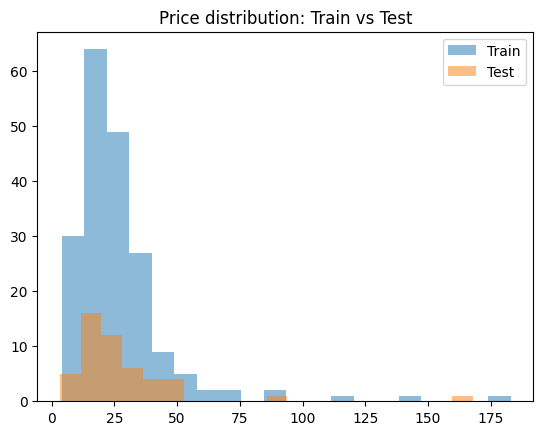

Train price mean: 26.558776165803106
Test price mean: 27.93224489795918


In [10]:
import matplotlib.pyplot as plt

# 对比训练和测试的实际价格分布
plt.hist(np.exp(y_train), bins=20, alpha=0.5, label='Train')
plt.hist(np.exp(y_test), bins=20, alpha=0.5, label='Test')
plt.legend()
plt.title('Price distribution: Train vs Test')
plt.show()

print("Train price mean:", np.exp(y_train).mean())
print("Test price mean:", np.exp(y_test).mean())

In [11]:
# Save as CSV (preserves column names)
X_train.to_csv('../data/processed/X_train_df.csv', index=False)
X_test.to_csv('../data/processed/X_test_df.csv', index=False)
y_train.to_csv('../data/processed/y_train_df.csv', index=False)
y_test.to_csv('../data/processed/y_test_df.csv', index=False)

## Evaluate feature importance

In [12]:
# Simple RF
rf = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

# Feature importance
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importance_features=importance[importance>0.01].index.to_list()
print(importance)

wheel_base                      0.455846
battery_capacity_avg            0.220594
width_mm                        0.138979
length_mm                       0.056650
brand_category_encoded          0.049173
size_large                      0.010179
depth_mm                        0.010063
brand_group_encoded             0.009262
range_CLTC_avg                  0.008747
size_other                      0.006166
year                            0.006157
battery_type_clean_LFP          0.004996
body_type_other                 0.004429
body_type_SUV                   0.003212
seats                           0.003190
battery_supplier_clean_CATL     0.002936
ADAS_Level_L2+                  0.002541
battery_type_clean_NCM          0.001905
size_small                      0.001153
ADAS_Level_L2                   0.000936
battery_type_clean_Other        0.000716
powertrain_纯电                   0.000540
battery_supplier_clean_Other    0.000538
powertrain_燃油                   0.000471
body_type_轿车    

In [13]:
# Save features with their importance values
with open('../data/processed/best_features.txt', 'w') as f:
    for feature in importance_features:
        f.write(feature+'\n')

print("Saved features with importance scores")

Saved features with importance scores
